# 02 - PatchCore Baseline
Runs PatchCore on a single category end-to-end.
Use this to understand the pipeline before running the full 15-category script.

**Start with `bottle` — it's the easiest category and will tell you if everything works.**

In [11]:
import sys
import importlib
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import src.models.patchcore as patchcore_module
import src.evaluation.metrics as metrics_module
patchcore_module = importlib.reload(patchcore_module)
metrics_module = importlib.reload(metrics_module)

from src.data.mvtec_dataset import get_dataloader
from src.models.patchcore import PatchCore
from src.evaluation.metrics import compute_all_metrics
from src.visualization.visualize import plot_anomaly_maps

MVTEC_ROOT = '../data/mvtec'
CATEGORY = 'bottle'   # Change this to test other categories
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_DIR = Path('../Model').resolve()
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(f'Using device: {DEVICE}')
print(f'Model weights dir: {MODEL_DIR}')

Using device: cuda
Model weights dir: D:\Programming\Projects\CV_Projects\mvtec_anomaly_detection_Phase_1\mvtec_anomaly_detection\Model


## Step 1: Load Data

In [2]:
train_loader = get_dataloader(
    root=MVTEC_ROOT, category=CATEGORY, split='train',
    image_size=(224, 224), batch_size=32, num_workers=4
)

test_loader = get_dataloader(
    root=MVTEC_ROOT, category=CATEGORY, split='test',
    image_size=(224, 224), batch_size=32, num_workers=4,
    return_masks=True
)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 7
Test batches: 3


## Step 2: Build Memory Bank (Fit)

In [3]:
model = PatchCore(
    backbone='wide_resnet50_2',
    layers=['layer2', 'layer3'],
    coreset_ratio=0.1,
    num_neighbors=9,
    device=DEVICE,
    weights_dir=MODEL_DIR,
)

model.fit(train_loader)

Building memory bank...


Extracting features: 100%|██████████| 7/7 [00:07<00:00,  1.04s/it]


Total patches: 163,856 | Applying coreset subsampling...


Memory bank size: 16,385 patches
Memory bank ready.


## Step 3: Predict

In [6]:
scores, anomaly_maps, labels = model.predict(test_loader)

# Collect masks
gt_masks = []
for batch in test_loader:
    gt_masks.append(batch['mask'].squeeze(1).numpy())
gt_masks = np.concatenate(gt_masks)

print(f'Scores shape: {scores.shape}')
print(f'Anomaly maps shape: {anomaly_maps.shape}')
print(f'Score range: [{scores.min():.4f}, {scores.max():.4f}]')
print(f'Normal samples: {(labels == 0).sum()} | Anomalous: {(labels == 1).sum()}')

Running inference: 100%|██████████| 3/3 [00:17<00:00,  5.68s/it]


Scores shape: (83,)
Anomaly maps shape: (83, 28, 28)
Score range: [1.7755, 25.0760]
Normal samples: 20 | Anomalous: 63


## Step 4: Compute Metrics

In [12]:
metrics = compute_all_metrics(labels, scores, gt_masks, anomaly_maps)

print(f"Image AUROC : {metrics['image_auroc']:.4f}")
print(f"Pixel AUROC : {metrics['pixel_auroc']:.4f}")
print(f"PRO Score   : {metrics['pro_score']:.4f}")

# Expected for 'bottle': Image AUROC ~0.998, Pixel AUROC ~0.981
# If your numbers are way off, check your data loading

Image AUROC : 1.0000
Pixel AUROC : 0.9853
PRO Score   : 0.7086


## Step 5: Visualize Anomaly Maps

Saved: ../results/patchcore/bottle/anomaly_maps.png


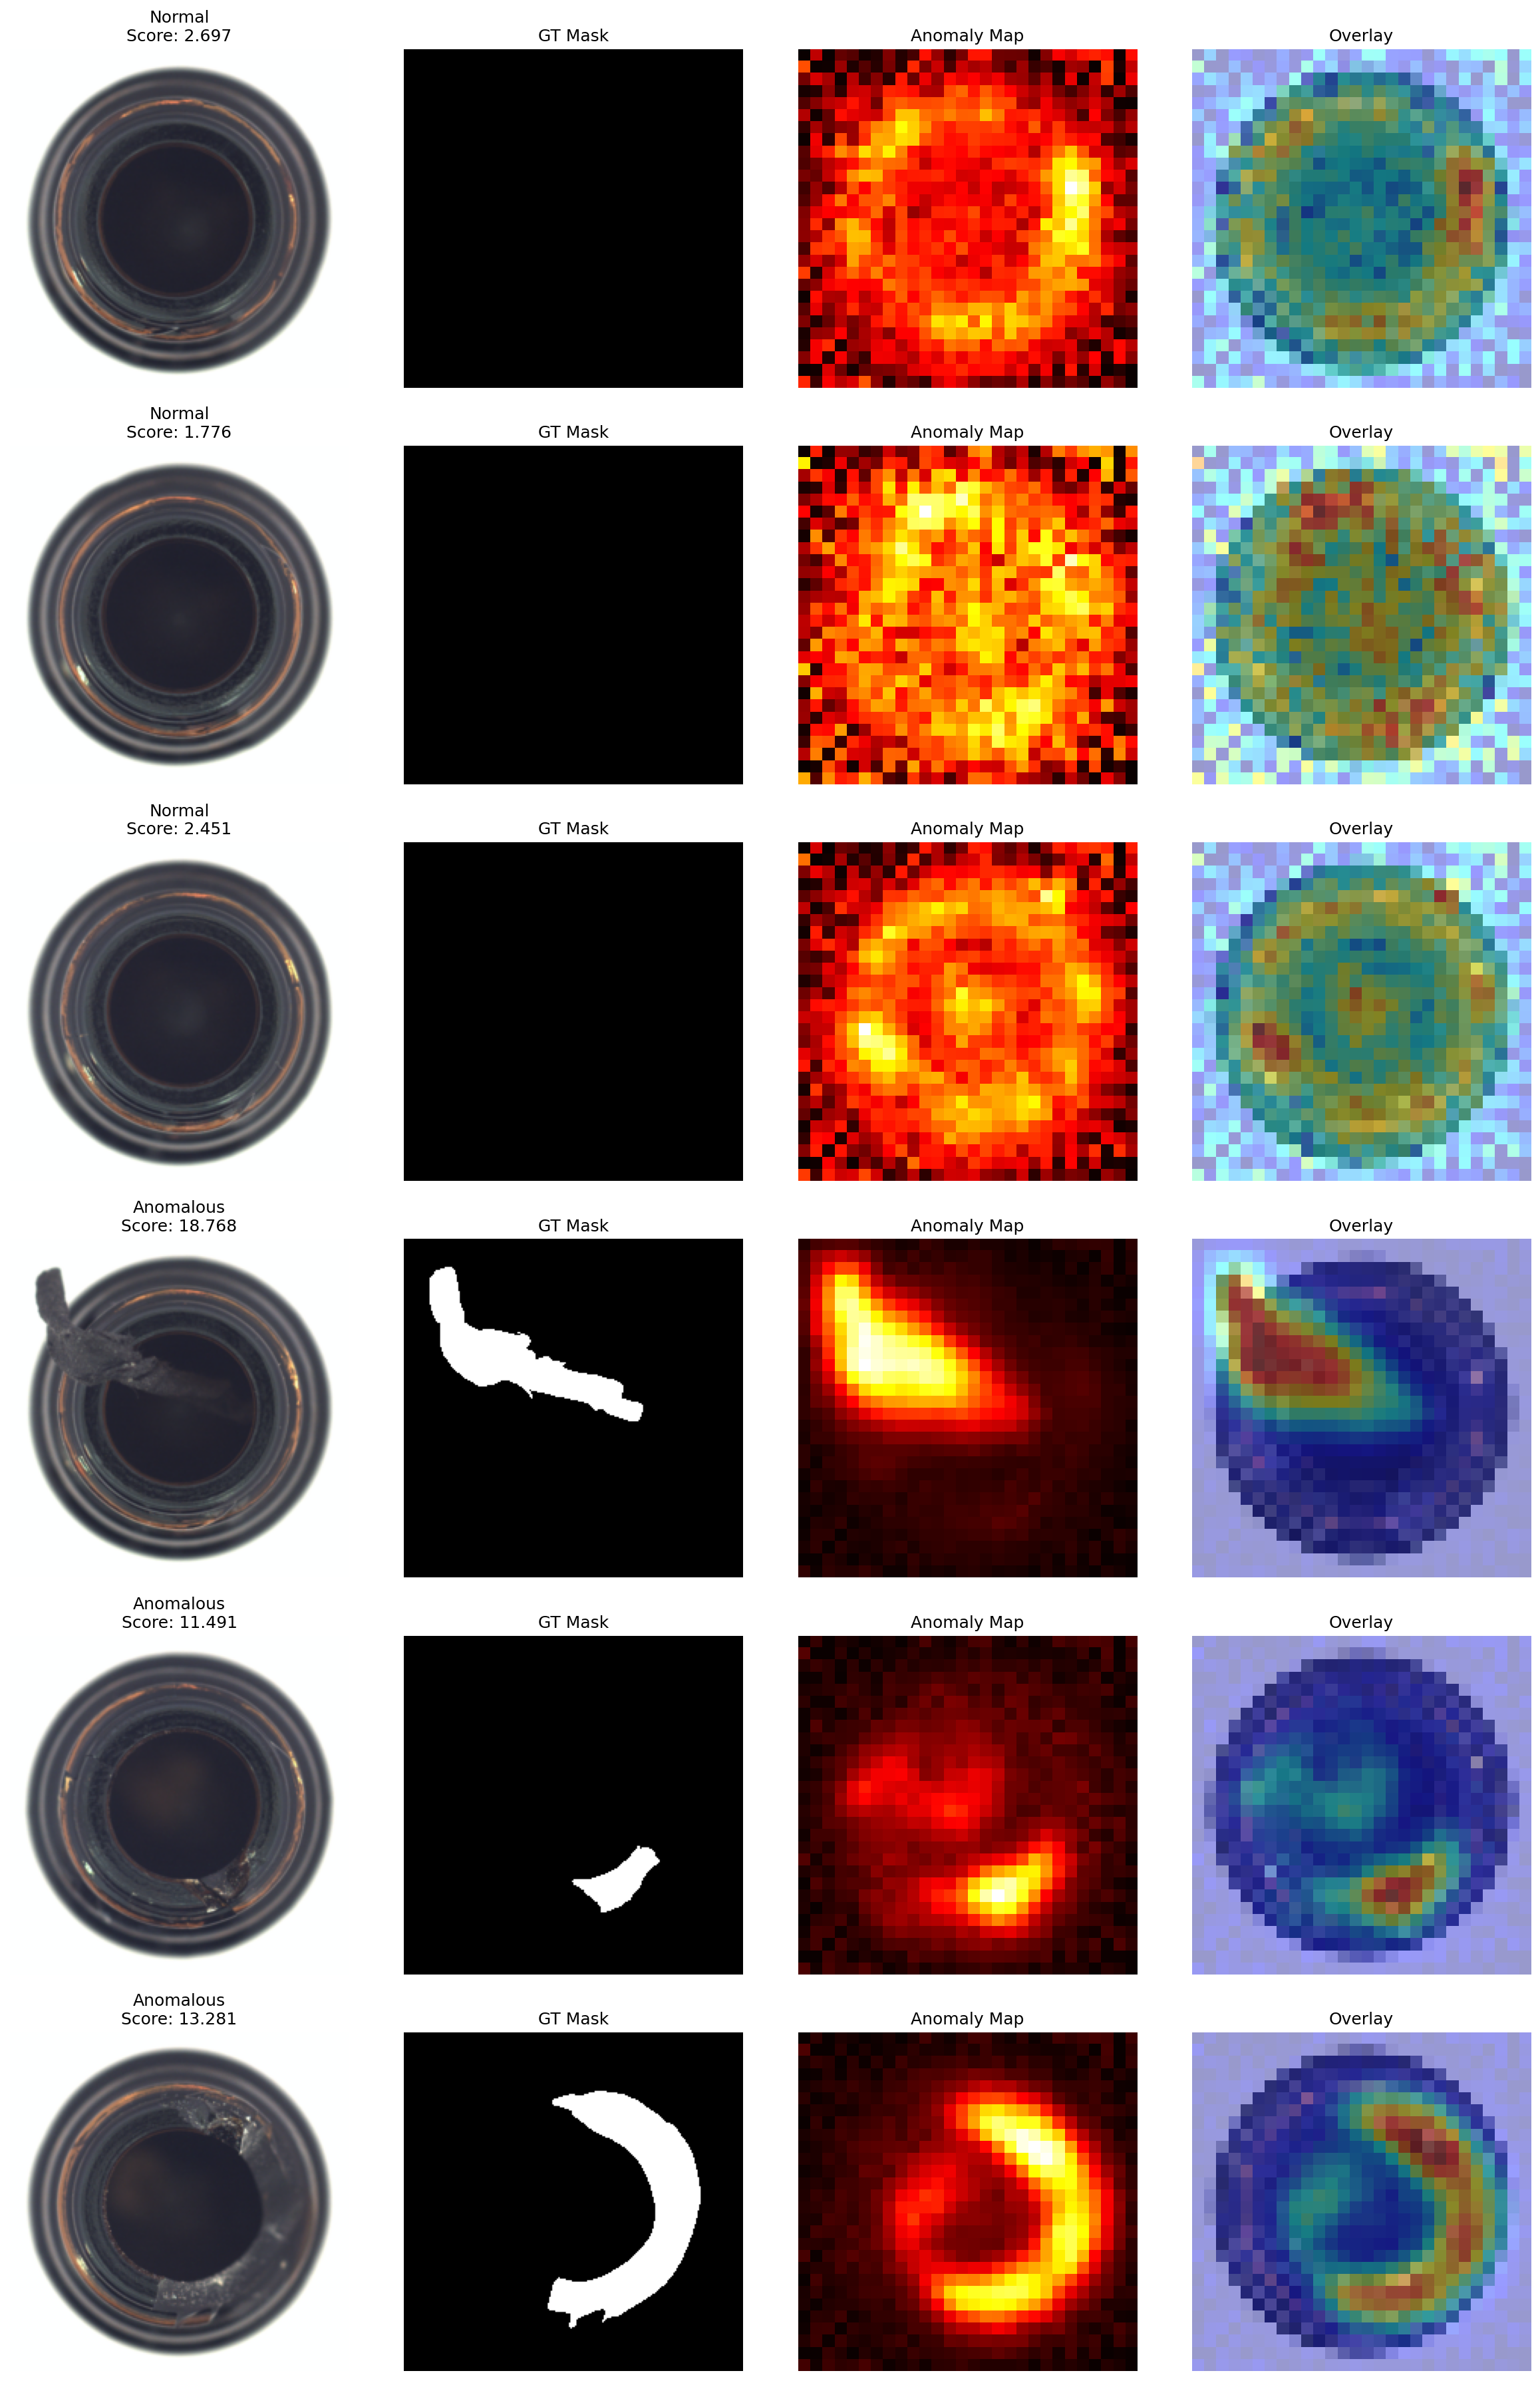

In [13]:
# Collect original images for visualization
import torchvision.transforms as T

# De-normalize images for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

all_images = []
for batch in test_loader:
    imgs = batch['image'].numpy()
    imgs = imgs.transpose(0, 2, 3, 1)  # BCHW -> BHWC
    imgs = (imgs * std + mean).clip(0, 1)
    all_images.append(imgs)
all_images = np.concatenate(all_images)

# Plot anomaly maps (this function defined in src/visualization/visualize.py)
plot_anomaly_maps(
    images=all_images,
    anomaly_maps=anomaly_maps,
    gt_masks=gt_masks,
    labels=labels,
    scores=scores,
    output_path=f'../results/patchcore/{CATEGORY}/anomaly_maps.png',
    n_samples=6,
)

# Display inline
from IPython.display import Image as IPImage
IPImage(filename=f'../results/patchcore/{CATEGORY}/anomaly_maps.png')

## Step 6: Failure Analysis

In [14]:
from src.evaluation.failure_analysis import generate_failure_report

# Collect image paths
image_paths = []
for batch in test_loader:
    image_paths.extend(batch['image_path'])

failure_df = generate_failure_report(
    category=CATEGORY,
    image_paths=image_paths,
    labels=labels,
    scores=scores,
    anomaly_maps=anomaly_maps,
    output_dir='../results/patchcore/failure_analysis',
)

print(failure_df['case_type'].value_counts())
failure_df.head(10)


[bottle] Threshold: 4.0823
  TP: 63 | TN: 20 | FP: 0 | FN: 0
No false_positive cases found.
No false_negative cases found.
case_type
true_positives    63
true_negatives    20
Name: count, dtype: int64


,category,image_path,true_label,anomaly_score,case_type
0,bottle,..\data\mvtec\bottle\test\broken_large\000.png,1,15.149918,true_positives
1,bottle,..\data\mvtec\bottle\test\broken_large\001.png,1,15.228550,true_positives
2,bottle,..\data\mvtec\bottle\test\broken_large\002.png,1,14.062008,true_positives
3,bottle,..\data\mvtec\bottle\test\broken_large\003.png,1,17.956791,true_positives
4,bottle,..\data\mvtec\bottle\test\broken_large\004.png,1,19.317032,true_positives
5,bottle,..\data\mvtec\bottle\test\broken_large\005.png,1,14.147476,true_positives
6,bottle,..\data\mvtec\bottle\test\broken_large\006.png,1,16.476910,true_positives
7,bottle,..\data\mvtec\bottle\test\broken_large\007.png,1,13.281952,true_positives
8,bottle,..\data\mvtec\bottle\test\broken_large\008.png,1,14.637791,true_positives
9,bottle,..\data\mvtec\bottle\test\broken_large\009.png,1,15.203167,true_positives


## Step 7: Experiment — Effect of Coreset Ratio
What happens to AUROC when you change how much of the memory bank you keep?

In [15]:
coreset_ratios = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]
auroc_results = []

for ratio in coreset_ratios:
    m = PatchCore(backbone='wide_resnet50_2', coreset_ratio=ratio, device=DEVICE)
    m.fit(train_loader)
    sc, _, lb = m.predict(test_loader)
    from src.evaluation.metrics import compute_image_auroc
    auroc = compute_image_auroc(lb, sc)
    auroc_results.append(auroc)
    print(f'Coreset ratio {ratio:.2f} -> Image AUROC: {auroc:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(coreset_ratios, auroc_results, 'o-', color='steelblue', linewidth=2)
plt.xlabel('Coreset Ratio')
plt.ylabel('Image AUROC')
plt.title(f'{CATEGORY} — AUROC vs. Coreset Ratio')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'../results/patchcore/{CATEGORY}/coreset_ablation.png', dpi=150)
plt.show()
print('This ablation plot goes in your GitHub README.')

Building memory bank...


Extracting features: 100%|██████████| 7/7 [00:07<00:00,  1.05s/it]


Total patches: 163,856 | Applying coreset subsampling...


Memory bank size: 1,638 patches
Memory bank ready.


Running inference: 100%|██████████| 3/3 [00:09<00:00,  3.14s/it]


Coreset ratio 0.01 -> Image AUROC: 1.0000
Building memory bank...


Extracting features: 100%|██████████| 7/7 [00:07<00:00,  1.01s/it]


Total patches: 163,856 | Applying coreset subsampling...


KeyboardInterrupt: 